In [21]:
#Define Imports
import abtem
abtem.config.set({"diagnostics.progress_bar": False})
import ase
from ase.cell import Cell
import numpy as np
import matplotlib.pyplot as plt
from abtem import orthogonalize_cell
from abtem import show_atoms
import os
from PIL import Image
from moviepy.editor import ImageSequenceClip 

In [22]:
# Run the Python script for twisted bilayer structure generation
%run twisted_bilayers.py

Text(0.5, 1.0, 'WSe2')

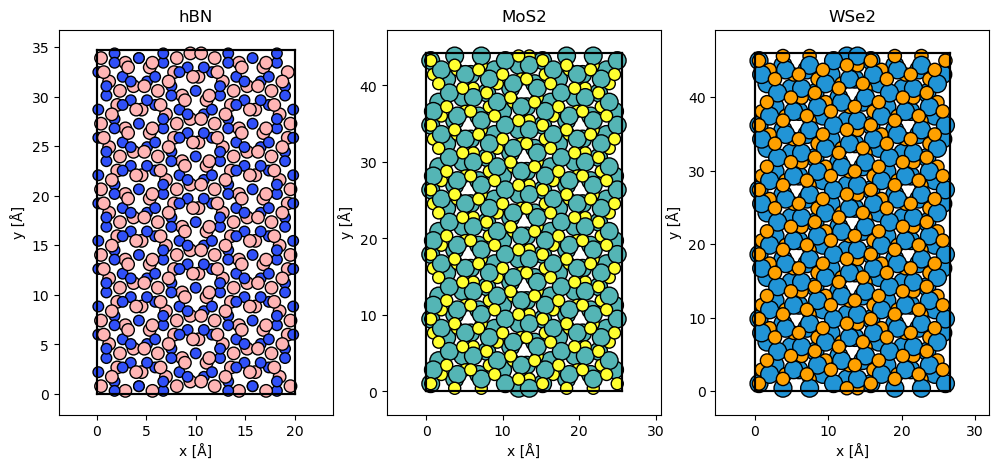

In [23]:
#Example Figure Creations

fig, axs = plt.subplots(1, 3, figsize=(12,5))
show_atoms(generate_twisted_bilayers('example CIFs/BN.cif', twist_angle=21.79), plane='xy', ax=axs[0])
show_atoms(generate_twisted_bilayers('example CIFs/MoS2.cif', twist_angle=21.79), plane='xy', ax=axs[1])
show_atoms(generate_twisted_bilayers('example CIFs/WSe2.cif', twist_angle=21.79), plane='xy', ax=axs[2])
axs[0].set_title('hBN')
axs[1].set_title('MoS2')
axs[2].set_title('WSe2')

In [24]:
def call_gen_twist(twist_angles, cif_file, out_dir):
    """
    Generates images of twisted bilayers according to inputted twist angles using twisted_bilayers.py file

    Parameters:
        - cif_file (str): Input structure file name (i.e. CIF, xyz, POSCAR, etc.)
            * NOTE: This will only work for structure files that only contain two layers within the unit cell.
        - twist_angle (array): List of twist angles (in degrees) to twist the bilayers about the z-axis
        - out_dir (str): Name of folder to save output images to

    Returns:
        - Structures (list): List of twisted structures
        - Image paths (list): List of image file paths, use to create gif
    """
    
    structures = []
    image_paths = []
    os.makedirs(out_dir, exist_ok=True)
 
    for i, twist in enumerate(twist_angles):
        struct = generate_twisted_bilayers(cif_file, twist_angle=twist)
        structures.append(struct)

        img, ax = show_atoms(struct, plane='xy', title=f"{twist}° Twist")

        frame_path = os.path.join(out_dir, f"dp_{i:03d}_{twist}deg.png")
        image_paths.append(frame_path)

        img.savefig(frame_path, bbox_inches='tight')
        plt.close(fig)

    plt.close('all')
        
    return structures, image_paths

In [25]:
# Known commensurate twist angles
# Source: https://github.com/cubanpit/graphene-bilayer-dft/blob/master/graphene_bilayer_rot.py

#commensurate_twist_angles = np.array([21.79, 13.17, 9.43, 7.34, 6.01, 5.09, 4.41, 3.89, 3.48, 2.65, 2.45, 2.13, 1.89, 1.79, 1.47, 1.05])
#commensurate_twist_angles = np.array([0, 1.05, 1.47, 1.79, 1.89, 2.13, 2.45, 2.65, 3.48, 3.89, 4.41, 5.09, 6.01, 7.34, 9.43, 13.17, 21.79])
# bn_cif = 'example CIFs/BN.cif'
# commensurate_twist_angles = np.round(np.linspace(0, 25, 100), 2)

# structure, hBn_image_paths = call_gen_twist(commensurate_twist_angles, bn_cif, 'Structure Images')

In [26]:
def calculate_potentials(structures_list, twist_angles):
    """
    Calculates potentials of twisted bilayers

    Parameters:
        - structures_list (list): Input list of twisted structures
        - twist_angle (array): List of twist angles (in degrees) to twist the bilayers about the z-axis

    Returns:
        - Potential List (list): List of potentials of twisted structure
    """

    potential_list = []

    for i in range(len(twist_angles)):
        frozen_phonons = abtem.FrozenPhonons(
            structures_list[i],
            num_configs=8,
            sigmas={'B': 0.1, 'N': 0.1},  # Thermal displacement in Å
        )

        potential = abtem.Potential(
            frozen_phonons,
            sampling=0.1,           # real-space sampling in Å/pixel
            slice_thickness=2.0,    # thickness of each projected slice in Å
            parametrization='kirkland',
        )
        potential_list.append(potential)
    
    return potential_list

In [27]:
def create_diffraction_patterns(potential_list, twist_angles):
    """
    Creates diffraction patterns of twisted bilayers, saves a folder of all diffraction pattern images and mean exit wave images

    Parameters:
        - potential_list (list): Input list of calculated frozen phonon potentials
        - twist_angle (array): List of twist angles (in degrees) to twist the bilayers about the z-axis

    Returns:
        - dp_list (list): List of diffraction patterns 
        - dp_frame_paths (list): List of file paths for diffraction patterns
        - exit_wave_frame_paths (list): List of file paths for exit waves
    """

    wave = abtem.PlaneWave(energy=300e3)  # energy in eV

    out_dir1 = "Diffraction Patterns"
    os.makedirs(out_dir1, exist_ok=True)
    out_dir2 = "Exit Waves"
    os.makedirs(out_dir2, exist_ok=True)
    dp_list = []
    dp_frame_paths = []
    exit_waves_frame_paths = []

    for i, angle in enumerate(twist_angles):
        title = f"{angle}° Twist"
        exit_wave = wave.multislice(potential_list[i])

        measurement = exit_wave.diffraction_patterns()
        dp_list.append(measurement)
        
        img = measurement.block_direct().show(power=0.3, title=title, cmap='inferno');
        figure = img.get_figure()

        frame_path1 = os.path.join(out_dir1, f"dp_{i:03d}_{angle}deg.png")
        frame_path2 = os.path.join(out_dir2, f"dp_{i:03d}_{angle}deg.png")

        img2 = exit_wave.intensity().mean(0).show(power=1, cmap='viridis', title=title);
        figure2 = img2.get_figure()

        figure2.savefig(frame_path2, bbox_inches='tight')

        figure.savefig(frame_path1, bbox_inches='tight')

        dp_frame_paths.append(frame_path1)
        exit_waves_frame_paths.append(frame_path2)

    plt.close('all')

    return dp_list, dp_frame_paths, exit_waves_frame_paths


In [28]:
def create_fig_mp4(fps, frame_paths, title):
    """
    Creates mp4 video of inputted pictures

    Parameters:
        - fps (int): frames per second rate, changes speed of video
        - frame_paths (list): Input list of paths of each images
        - title (string): String to save video as file

    Returns:
        - None
    """
    
    clip = ImageSequenceClip(frame_paths, fps=fps)
    clip.write_videofile(title, codec="libx264", audio=False)

In [29]:
def run_pipeline(twist_angles, cif_file):
    """
    Runs all functions in one pipeline to generate videos of the structures, diffraction patterns, and exit waves changing with twist angle

    Parameters:
        - twist_angles (array): twist angles
        - cif_file (str): Name of cif file containing desired structure

    Returns:
        - None
    """

    structure, image_paths = call_gen_twist(twist_angles, cif_file, 'Structure Images')
    potential_list = calculate_potentials(structure, twist_angles)
    dp_list, dp_frame_paths, exit_waves_frame_paths = create_diffraction_patterns(potential_list, twist_angles)

    create_fig_mp4(16, image_paths, 'Structure Animation.mp4')
    create_fig_mp4(16, dp_frame_paths, 'Diffraction Animation.mp4')
    create_fig_mp4(16, exit_waves_frame_paths, 'Exit Waves Animation.mp4')

In [30]:
commensurate_twist_angles = np.round(np.linspace(0, 25, 100), 2)
bn_cif = 'example CIFs/BN.cif'

#Example pipeline run
run_pipeline(commensurate_twist_angles, bn_cif)

Moviepy - Building video Structure Animation.mp4.
Moviepy - Writing video Structure Animation.mp4



Moviepy - Done !
Moviepy - video ready Structure Animation.mp4
Moviepy - Building video Diffraction Animation.mp4.
Moviepy - Writing video Diffraction Animation.mp4



Moviepy - Done !
Moviepy - video ready Diffraction Animation.mp4
Moviepy - Building video Exit Waves Animation.mp4.
Moviepy - Writing video Exit Waves Animation.mp4



Moviepy - Done !
Moviepy - video ready Exit Waves Animation.mp4
